In [1]:
import pandas as pd
from pathlib import Path

In [2]:
! python -m pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Project Root
Project_Root = Path.cwd().parent

# Data Directory
RAW_DATA_DIR = Project_Root / "data" / "raw"

# File paths
occupation_path = RAW_DATA_DIR / "Occupation Data.xlsx"
job_titles_path = RAW_DATA_DIR / "Job Titles.xlsx"
essential_skills_path = RAW_DATA_DIR / "Essential Skills.xlsx"
software_skills_path = RAW_DATA_DIR / "Software Skills.xlsx"

In [4]:
# Load
occupation_df = pd.read_excel(occupation_path)
job_titles_df = pd.read_excel(job_titles_path)
essential_skills_df = pd.read_excel(essential_skills_path)
software_skills_df = pd.read_excel(software_skills_path)

In [5]:
print("Occupation Data:", occupation_df.shape)
print("Job Titles:", job_titles_df.shape)
print("Essential Skills:", essential_skills_df.shape)
print("Software Skills:", software_skills_df.shape)

Occupation Data: (1016, 3)
Job Titles: (54269, 5)
Essential Skills: (18200, 15)
Software Skills: (31821, 7)


In [6]:
print("\nOccupation Data columns:")
print(occupation_df.columns.tolist())

print("\nJob Titles columns:")
print(job_titles_df.columns.tolist())

print("\nEssential Skills columns:")
print(essential_skills_df.columns.tolist())

print("\nSoftware Skills columns:")
print(software_skills_df.columns.tolist())


Occupation Data columns:
['O*NET-SOC Code', 'Title', 'Description']

Job Titles columns:
['O*NET-SOC Code', 'Title', 'Job Title', 'Short Title', 'Source(s)']

Essential Skills columns:
['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Not Relevant', 'Date', 'Domain Source']

Software Skills columns:
['O*NET-SOC Code', 'Title', 'Workplace Example', 'Element ID', 'Element Name', 'Hot Technology', 'In Demand']


In [7]:
soc_code = "15-2051.00"
occupation_df[
    occupation_df["O*NET-SOC Code"] == soc_code
]
job_titles_df[
    job_titles_df["O*NET-SOC Code"] == soc_code
].head(10)


,O*NET-SOC Code,Title,Job Title,Short Title,Source(s)
5642,15-2051.00,Data Scientists,Analytics Consultant,NaN,08
5643,15-2051.00,Data Scientists,Applied Scientist,NaN,08
5644,15-2051.00,Data Scientists,Data Analyst,NaN,08
5645,15-2051.00,Data Scientists,Data Analytic Scientist,NaN,08
5646,15-2051.00,Data Scientists,Data Analytics Scientist,NaN,10
5647,15-2051.00,Data Scientists,Data Analytics Specialist,NaN,"04,08"
5648,15-2051.00,Data Scientists,Data Architect,NaN,08
5649,15-2051.00,Data Scientists,Data Consultant,NaN,08
5650,15-2051.00,Data Scientists,Data Economist,NaN,08
5651,15-2051.00,Data Scientists,Data Engineer,NaN,08


In [8]:
essential_skills_df[
    essential_skills_df["O*NET-SOC Code"] == soc_code
][
    ["Element Name", "Scale Name", "Data Value", "Not Relevant"]
].head(20)

,Element Name,Scale Name,Data Value,Not Relevant
2660,Reading Comprehension,Importance,3.88,NaN
2661,Reading Comprehension,Level,4.62,N
2662,Active Listening,Importance,3.50,NaN
2663,Active Listening,Level,3.75,N
2664,Writing,Importance,3.50,NaN
2665,Writing,Level,4.12,N
2666,Speaking,Importance,3.62,NaN
2667,Speaking,Level,3.75,N
2668,Mathematics,Importance,4.38,NaN
2669,Mathematics,Level,5.00,N


In [9]:
software_skills_df[
    software_skills_df["O*NET-SOC Code"] == soc_code
][
    ["Workplace Example", "Element Name", "Hot Technology", "In Demand"]
].head(20)

,Workplace Example,Element Name,Hot Technology,In Demand
11865,Alteryx software,Business intelligence and data analysis software,Y,N
11866,Amazon Elastic Compute Cloud EC2,Data base user interface and query software,Y,N
11867,Amazon Redshift,Data base user interface and query software,Y,N
11868,Amazon Simple Storage Service S3,Storage networking software,N,N
11869,Amazon Web Services AWS SageMaker,Cloud-based management software,N,N
11870,Amazon Web Services AWS software,Data base user interface and query software,Y,Y
11871,Apache Airflow,Procedure management software,Y,N
11872,Apache Cassandra,Data base management system software,Y,N
11873,Apache Hadoop,Data base management system software,Y,Y
11874,Apache Hive,Data base management system software,Y,N


## O*NET Data Cleaning and Aggregation

The raw O*NET datasets contain multiple records for each occupation.
These datasets are aggregated by O*NET-SOC Code to create one profile
for each occupation.

In [10]:
job_titles_agg = (
    job_titles_df
    .groupby("O*NET-SOC Code")["Job Title"]
    .apply(lambda x: sorted(set(x.dropna())))
    .reset_index()
)

job_titles_agg.head()

,O*NET-SOC Code,Job Title
0,11-1011.00,"[Aeronautics Commission Director, Agency Owner..."
1,11-1011.03,[CSR and Sustainability VP (Corporate Social R...
2,11-1021.00,"[Area Manager, Boards and Commissions Director..."
3,11-1031.00,"[Alderman, Assembly Member, Assembly Person, A..."
4,11-2011.00,"[Account Executive, Account Manager, Ad Accoun..."


In [11]:
job_titles_agg = job_titles_agg.rename(
    columns={"Job Title": "Alternate Job Titles"}
)

job_titles_agg.head()

,O*NET-SOC Code,Alternate Job Titles
0,11-1011.00,"[Aeronautics Commission Director, Agency Owner..."
1,11-1011.03,[CSR and Sustainability VP (Corporate Social R...
2,11-1021.00,"[Area Manager, Boards and Commissions Director..."
3,11-1031.00,"[Alderman, Assembly Member, Assembly Person, A..."
4,11-2011.00,"[Account Executive, Account Manager, Ad Accoun..."


In [12]:
job_titles_agg[
    job_titles_agg["O*NET-SOC Code"] == "15-2051.00"
]

,O*NET-SOC Code,Alternate Job Titles
142,15-2051.00,"[Analytics Consultant, Applied Scientist, Data..."


In [13]:
data_scientist_title_count = len(
    job_titles_agg.loc[
        job_titles_agg["O*NET-SOC Code"] == "15-2051.00",
        "Alternate Job Titles"
    ].iloc[0]
)

print("Number of alternate job titles for Data Scientists:", data_scientist_title_count)


Number of alternate job titles for Data Scientists: 29


In [14]:
essential_skills_pivot = essential_skills_df.pivot_table(
    index=["O*NET-SOC Code", "Element Name"],
    columns="Scale Name",
    values="Data Value",
    aggfunc="first"
).reset_index()

essential_skills_pivot.head(10)

Scale Name,O*NET-SOC Code,Element Name,Importance,Level
0,11-1011.00,Active Learning,3.75,4.50
1,11-1011.00,Active Listening,4.00,4.75
2,11-1011.00,Critical Thinking,4.38,4.75
3,11-1011.00,Learning Strategies,3.12,3.75
4,11-1011.00,Mathematics,3.25,3.50
5,11-1011.00,Monitoring,4.00,5.25
6,11-1011.00,Reading Comprehension,4.12,4.62
7,11-1011.00,Science,1.62,0.75
8,11-1011.00,Speaking,4.25,4.75
9,11-1011.00,Writing,4.12,4.38


In [15]:
data_scientist_skills = essential_skills_pivot[
    essential_skills_pivot["O*NET-SOC Code"] == "15-2051.00"
]

print(data_scientist_skills)
print("\nNumber of essential skills:", len(data_scientist_skills))

Scale Name O*NET-SOC Code           Element Name  Importance  Level
1330           15-2051.00        Active Learning        3.62   4.38
1331           15-2051.00       Active Listening        3.50   3.75
1332           15-2051.00      Critical Thinking        4.25   4.62
1333           15-2051.00    Learning Strategies        2.75   3.00
1334           15-2051.00            Mathematics        4.38   5.00
1335           15-2051.00             Monitoring        3.25   3.62
1336           15-2051.00  Reading Comprehension        3.88   4.62
1337           15-2051.00                Science        2.50   2.12
1338           15-2051.00               Speaking        3.62   3.75
1339           15-2051.00                Writing        3.50   4.12

Number of essential skills: 10


In [16]:
essential_skills_agg = (
    essential_skills_pivot
    .groupby("O*NET-SOC Code")
    .apply(
        lambda group: group[
            ["Element Name", "Importance", "Level"]
        ].to_dict("records"),
        include_groups=False
    )
    .reset_index(name="Essential Skills")
)

essential_skills_agg.head()

,O*NET-SOC Code,Essential Skills
0,11-1011.00,"[{'Element Name': 'Active Learning', 'Importan..."
1,11-1011.03,"[{'Element Name': 'Active Learning', 'Importan..."
2,11-1021.00,"[{'Element Name': 'Active Learning', 'Importan..."
3,11-2011.00,"[{'Element Name': 'Active Learning', 'Importan..."
4,11-2021.00,"[{'Element Name': 'Active Learning', 'Importan..."


In [17]:
data_scientist_essential = essential_skills_agg[
    essential_skills_agg["O*NET-SOC Code"] == "15-2051.00"
]

print("Number of occupation rows:", len(data_scientist_essential))

print(
    "Number of essential skills:",
    len(data_scientist_essential.iloc[0]["Essential Skills"])
)

data_scientist_essential.iloc[0]["Essential Skills"]

Number of occupation rows: 1
Number of essential skills: 10


[{'Element Name': 'Active Learning', 'Importance': 3.62, 'Level': 4.38},
 {'Element Name': 'Active Listening', 'Importance': 3.5, 'Level': 3.75},
 {'Element Name': 'Critical Thinking', 'Importance': 4.25, 'Level': 4.62},
 {'Element Name': 'Learning Strategies', 'Importance': 2.75, 'Level': 3.0},
 {'Element Name': 'Mathematics', 'Importance': 4.38, 'Level': 5.0},
 {'Element Name': 'Monitoring', 'Importance': 3.25, 'Level': 3.62},
 {'Element Name': 'Reading Comprehension', 'Importance': 3.88, 'Level': 4.62},
 {'Element Name': 'Science', 'Importance': 2.5, 'Level': 2.12},
 {'Element Name': 'Speaking', 'Importance': 3.62, 'Level': 3.75},
 {'Element Name': 'Writing', 'Importance': 3.5, 'Level': 4.12}]

In [18]:
software_skills_agg = (
    software_skills_df
    .groupby("O*NET-SOC Code")
    .apply(
        lambda group: group[
            [
                "Workplace Example",
                "Element Name",
                "Hot Technology",
                "In Demand"
            ]
        ].drop_duplicates().to_dict("records"),
        include_groups=False
    )
    .reset_index(name="Software Skills")
)

software_skills_agg.head()

,O*NET-SOC Code,Software Skills
0,11-1011.00,"[{'Workplace Example': 'Adobe Acrobat', 'Eleme..."
1,11-1011.03,"[{'Workplace Example': 'Adobe Acrobat', 'Eleme..."
2,11-1021.00,"[{'Workplace Example': 'Act!', 'Element Name':..."
3,11-1031.00,"[{'Workplace Example': 'Adobe Acrobat', 'Eleme..."
4,11-2011.00,"[{'Workplace Example': 'Actuate BIRT', 'Elemen..."


In [19]:
data_scientist_software = software_skills_agg[
    software_skills_agg["O*NET-SOC Code"] == "15-2051.00"
]

print("Number of occupation rows:", len(data_scientist_software))

print(
    "Number of software skills:",
    len(data_scientist_software.iloc[0]["Software Skills"])
)

Number of occupation rows: 1
Number of software skills: 87


In [20]:
occupation_profiles_df = (
    occupation_df
    .merge(
        job_titles_agg,
        on="O*NET-SOC Code",
        how="left"
    )
    .merge(
        essential_skills_agg,
        on="O*NET-SOC Code",
        how="left"
    )
    .merge(
        software_skills_agg,
        on="O*NET-SOC Code",
        how="left"
    )
)

print("Final dataset shape:", occupation_profiles_df.shape)

occupation_profiles_df.head()

Final dataset shape: (1016, 6)


,O*NET-SOC Code,Title,Description,Alternate Job Titles,Essential Skills,Software Skills
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,"[Aeronautics Commission Director, Agency Owner...","[{'Element Name': 'Active Learning', 'Importan...","[{'Workplace Example': 'Adobe Acrobat', 'Eleme..."
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh...",[CSR and Sustainability VP (Corporate Social R...,"[{'Element Name': 'Active Learning', 'Importan...","[{'Workplace Example': 'Adobe Acrobat', 'Eleme..."
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...","[Area Manager, Boards and Commissions Director...","[{'Element Name': 'Active Learning', 'Importan...","[{'Workplace Example': 'Act!', 'Element Name':..."
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes...","[Alderman, Assembly Member, Assembly Person, A...",NaN,"[{'Workplace Example': 'Adobe Acrobat', 'Eleme..."
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...","[Account Executive, Account Manager, Ad Accoun...","[{'Element Name': 'Active Learning', 'Importan...","[{'Workplace Example': 'Actuate BIRT', 'Elemen..."


In [21]:
print("Total occupation profiles:", len(occupation_profiles_df))

print(
    "Unique O*NET-SOC Codes:",
    occupation_profiles_df["O*NET-SOC Code"].nunique()
)

print(
    "Duplicate O*NET-SOC Codes:",
    occupation_profiles_df["O*NET-SOC Code"].duplicated().sum()
)

print("\nMissing values:")
print(occupation_profiles_df.isnull().sum())

Total occupation profiles: 1016
Unique O*NET-SOC Codes: 1016
Duplicate O*NET-SOC Codes: 0

Missing values:
O*NET-SOC Code            0
Title                     0
Description               0
Alternate Job Titles      0
Essential Skills        106
Software Skills          93
dtype: int64


In [22]:
data_scientist_profile = occupation_profiles_df[
    occupation_profiles_df["O*NET-SOC Code"] == "15-2051.00"
]

print("Occupation:", data_scientist_profile.iloc[0]["Title"])
print(
    "Alternate Job Titles:",
    len(data_scientist_profile.iloc[0]["Alternate Job Titles"])
)
print(
    "Essential Skills:",
    len(data_scientist_profile.iloc[0]["Essential Skills"])
)
print(
    "Software Skills:",
    len(data_scientist_profile.iloc[0]["Software Skills"])
)

Occupation: Data Scientists
Alternate Job Titles: 29
Essential Skills: 10
Software Skills: 87


In [23]:
PROCESSED_DATA_DIR = Project_Root / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

output_path = PROCESSED_DATA_DIR / "occupation_profiles.pkl"

occupation_profiles_df.to_pickle(output_path)

print("Saved successfully to:", output_path)
print("Final shape:", occupation_profiles_df.shape)

Saved successfully to: c:\Users\shrut\OneDrive - UNT System\Fall 2026\Capstone\project\CareerMatch_AI\data\processed\occupation_profiles.pkl
Final shape: (1016, 6)


In [24]:
data_scientist_skills = essential_skills_pivot[
    essential_skills_pivot["O*NET-SOC Code"] == "15-2051.00"
][["Element Name", "Importance", "Level"]]

data_scientist_skills

Scale Name,Element Name,Importance,Level
1330,Active Learning,3.62,4.38
1331,Active Listening,3.50,3.75
1332,Critical Thinking,4.25,4.62
1333,Learning Strategies,2.75,3.00
1334,Mathematics,4.38,5.00
1335,Monitoring,3.25,3.62
1336,Reading Comprehension,3.88,4.62
1337,Science,2.50,2.12
1338,Speaking,3.62,3.75
1339,Writing,3.50,4.12


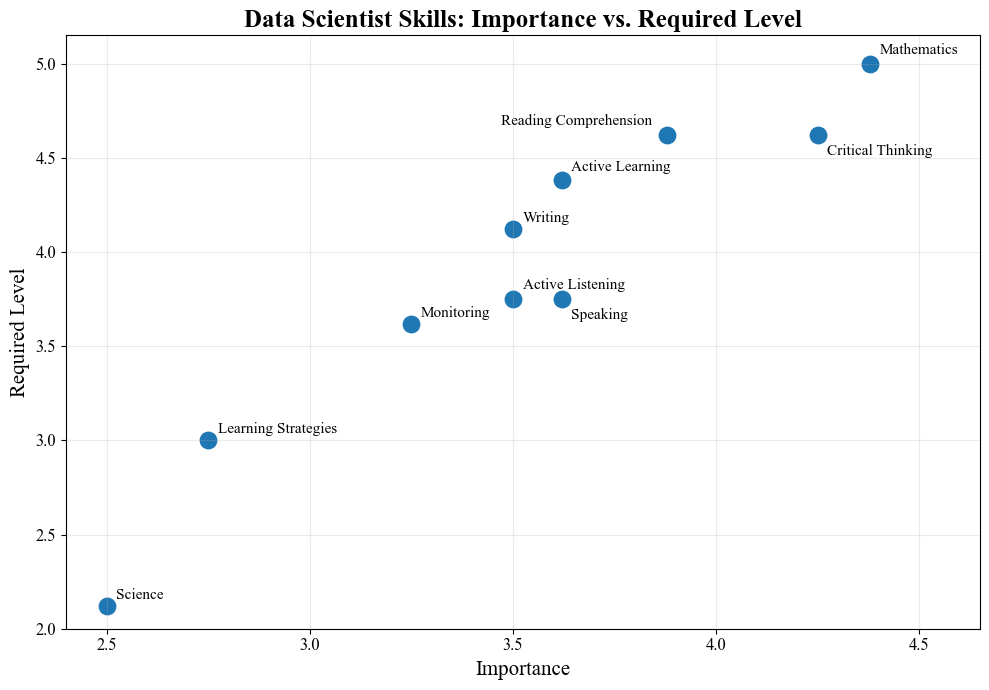

In [28]:
import matplotlib.pyplot as plt

# Use the same font as the poster
plt.rcParams["font.family"] = "Times New Roman"

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot
ax.scatter(
    data_scientist_skills["Importance"],
    data_scientist_skills["Level"],
    s=140
)

# Custom label positions to avoid overlap
label_offsets = {
    "Active Learning": (7, 7),
    "Active Listening": (7, 7),
    "Critical Thinking": (7, -14),
    "Learning Strategies": (7, 5),
    "Mathematics": (7, 7),
    "Monitoring": (7, 5),
    "Reading Comprehension": (-120, 7),
    "Science": (7, 5),
    "Speaking": (7, -14),
    "Writing": (7, 5)
}

# Add skill labels
for _, row in data_scientist_skills.iterrows():

    skill_name = row["Element Name"]
    offset = label_offsets[skill_name]

    ax.annotate(
        skill_name,
        (row["Importance"], row["Level"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=11
    )

# Axis labels
ax.set_xlabel(
    "Importance",
    fontsize=15
)

ax.set_ylabel(
    "Required Level",
    fontsize=15
)

# Title
ax.set_title(
    "Data Scientist Skills: Importance vs. Required Level",
    fontsize=18,
    fontweight="bold"
)

# Give labels enough space
ax.set_xlim(2.4, 4.65)
ax.set_ylim(2.0, 5.15)

# Tick size
ax.tick_params(
    axis="both",
    labelsize=12
)

# Light grid for readability
ax.grid(
    alpha=0.25
)

# Prevent clipping
plt.tight_layout()

# Display
plt.show()